In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("所有库导入成功！")
print(f"pandas版本: {pd.__version__}")

所有库导入成功！
pandas版本: 2.3.3


In [4]:
import os

# 检查数据文件
data_path = '../data/'
files = os.listdir(data_path)
print("data文件夹中的文件:")
for f in files:
    print(f"  - {f}")

data文件夹中的文件:
  - .gitkeep
  - testA.csv
  - train.csv


In [5]:
import os
data_path = '../data/'
files = os.listdir(data_path)
print("data文件夹中的文件:")
for f in files:
    print(f"  - {f}")

data文件夹中的文件:
  - .gitkeep
  - testA.csv
  - train.csv


In [6]:
train = pd.read_csv('../data/train.csv', sep=' ')
test = pd.read_csv('../data/testA.csv', sep=' ')
print(f"训练集形状: {train.shape}")
print(f"测试集形状: {test.shape}")
print("\n训练集前5行:")
train.head()

训练集形状: (150000, 31)
测试集形状: (50000, 30)

训练集前5行:


,SaleID,name,regDate,model,brand,bodyType,fuelType,gearbox,power,kilometer,...,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,v_13,v_14
0,0,736,20040402,30.0,6,1.0,0.0,0.0,60,12.5,...,0.235676,0.101988,0.129549,0.022816,0.097462,-2.881803,2.804097,-2.420821,0.795292,0.914762
1,1,2262,20030301,40.0,1,2.0,0.0,0.0,0,15.0,...,0.264777,0.121004,0.135731,0.026597,0.020582,-4.900482,2.096338,-1.030483,-1.722674,0.245522
2,2,14874,20040403,115.0,15,1.0,0.0,0.0,163,12.5,...,0.251410,0.114912,0.165147,0.062173,0.027075,-4.846749,1.803559,1.565330,-0.832687,-0.229963
3,3,71865,19960908,109.0,10,0.0,0.0,1.0,193,15.0,...,0.274293,0.110300,0.121964,0.033395,0.000000,-4.509599,1.285940,-0.501868,-2.438353,-0.478699
4,4,111080,20120103,110.0,5,1.0,0.0,0.0,68,5.0,...,0.228036,0.073205,0.091880,0.078819,0.121534,-1.896240,0.910783,0.931110,2.834518,1.923482


In [7]:
print("\n测试集前5行:")
test.head()


测试集前5行:


,SaleID,name,regDate,model,brand,bodyType,fuelType,gearbox,power,kilometer,...,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,v_13,v_14
0,150000,66932,20111212,222.0,4,5.0,1.0,1.0,313,15.0,...,0.264405,0.121800,0.070899,0.106558,0.078867,-7.050969,-0.854626,4.800151,0.620011,-3.664654
1,150001,174960,19990211,19.0,21,0.0,0.0,0.0,75,12.5,...,0.261745,0.000000,0.096733,0.013705,0.052383,3.679418,-0.729039,-3.796107,-1.541230,-0.757055
2,150002,5356,20090304,82.0,21,0.0,0.0,0.0,109,7.0,...,0.260216,0.112081,0.078082,0.062078,0.050540,-4.926690,1.001106,0.826562,0.138226,0.754033
3,150003,50688,20100405,0.0,0,0.0,0.0,1.0,160,7.0,...,0.260466,0.106727,0.081146,0.075971,0.048268,-4.864637,0.505493,1.870379,0.366038,1.312775
4,150004,161428,19970703,26.0,14,2.0,0.0,0.0,75,15.0,...,0.250999,0.000000,0.077806,0.028600,0.081709,3.616475,-0.673236,-3.197685,-0.025678,-0.101290


In [8]:
print(train.info());
print('-----------');
print(test.info());

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SaleID             150000 non-null  int64  
 1   name               150000 non-null  int64  
 2   regDate            150000 non-null  int64  
 3   model              149999 non-null  float64
 4   brand              150000 non-null  int64  
 5   bodyType           145494 non-null  float64
 6   fuelType           141320 non-null  float64
 7   gearbox            144019 non-null  float64
 8   power              150000 non-null  int64  
 9   kilometer          150000 non-null  float64
 10  notRepairedDamage  150000 non-null  object 
 11  regionCode         150000 non-null  int64  
 12  seller             150000 non-null  int64  
 13  offerType          150000 non-null  int64  
 14  creatDate          150000 non-null  int64  
 15  price              150000 non-null  int64  
 16  v_

In [35]:
print('训练集的特殊值')
train['notRepairedDamage'].value_counts()

训练集的特殊值


notRepairedDamage
0.0    111361
-       24324
1.0     14315
Name: count, dtype: int64

In [41]:
print('测试集的值')
test['notRepairedDamage'].value_counts()

测试集的值


notRepairedDamage
0.0    37249
-       8031
1.0     4720
Name: count, dtype: int64

In [42]:
print('训练集空值')
print(train[['fuelType','gearbox']].isnull().sum())
print('测试集nan值')
print(test[['fuelType','gearbox']].isnull().sum())

训练集空值
fuelType    0
gearbox     0
dtype: int64
测试集nan值
fuelType    0
gearbox     0
dtype: int64


In [43]:
train['fuelType']=train['fuelType'].fillna(train['fuelType'].mode()[0])
test['fuelType']=test['fuelType'].fillna(test['fuelType'].mode()[0])

In [44]:
train['gearbox']=train['gearbox'].fillna(train['gearbox'].mode()[0])
test['gearbox']=test['gearbox'].fillna(test['gearbox'].mode()[0])

In [45]:
print('训练集nan值')
print(train[['fuelType','gearbox']].isnull().sum())
print('测试集nan值')
print(test[['fuelType','gearbox']].isnull().sum())

训练集nan值
fuelType    0
gearbox     0
dtype: int64
测试集nan值
fuelType    0
gearbox     0
dtype: int64


In [46]:
print("燃料异常数据：")
print(train['fuelType'].unique())
print(test['fuelType'].unique())

燃料异常数据：
[0. 1. 2. 3. 4. 5. 6.]
[1. 0. 3. 2. 4. 6. 5.]


In [47]:
print("车型异常值:")
print(train['bodyType'].unique())
print(test['bodyType'].unique())
print('销售方异常数据：')
print(train['seller'].unique())
print(test['seller'].unique())

车型异常值:
[ 1.  2.  0.  5.  3. nan  6.  7.  4.]
[ 5.  0.  2.  3.  6.  1. nan  4.  7.]
销售方异常数据：
[0 1]
[0]


In [48]:
df_clean=train.dropna(subset=['fuelType','bodyType'])

In [49]:
print("燃料异常数据：")
print(df_clean['fuelType'].unique())
print("车型异常值:")
print(df_clean['bodyType'].unique())

燃料异常数据：
[0. 1. 2. 3. 4. 5. 6.]
车型异常值:
[1. 2. 0. 5. 3. 6. 7. 4.]


In [50]:
print('power异常数据量：')
print(train[train['power']==0].shape)

power异常数据量：
(0, 40)


In [51]:
median_power=train[train['power']>0]['power'].median()
train['power']=train['power'].replace(0,median_power)

In [52]:
from sklearn.preprocessing import LabelEncoder
from datetime import datetime

In [53]:
def process_date(date_str):#构造日期函数,开始计算特征值
    date_str=str(date_str)
    if len(date_str)!=8:
        return pd.Series([np.nan,np.nan,np.nan])
    return pd.Series([
        int(date_str[:4]),
        int(date_str[4:6]),
        int(date_str[6:8])],index=['年','月','日'])

In [54]:
train.head().T

,0,1,2,3,4
SaleID,0,1,2,3,4
name,736,2262,14874,71865,111080
regDate,20040402,20030301,20040403,19960908,20120103
model,30.0,40.0,115.0,109.0,110.0
brand,6,1,15,10,5
bodyType,1.0,2.0,1.0,0.0,1.0
fuelType,0.0,0.0,0.0,0.0,0.0
gearbox,0.0,0.0,0.0,1.0,0.0
power,60,116,163,193,68
kilometer,12.5,15.0,12.5,15.0,5.0


In [55]:
for df in[train,test]:
    df[['reg_year','reg_month','reg_day']]=df['regDate'].apply(process_date)
    df[['cre_year','cre_month','day']]=df['creatDate'].apply(process_date)
    df['carage']=df['cre_year']-df['reg_year']
    df['carage']=df['carage'].clip(0,50)

In [56]:
for df in[train,test]:
    df['distance']=df['kilometer']/(0.1+df['carage'])
    df['power_perkilo']=df['power']/(0.1+df['kilometer'])

In [57]:
train.head().T

,0,1,2,3,4
SaleID,0,1,2,3,4
name,736,2262,14874,71865,111080
regDate,20040402,20030301,20040403,19960908,20120103
model,30.0,40.0,115.0,109.0,110.0
brand,6,1,15,10,5
bodyType,1.0,2.0,1.0,0.0,1.0
fuelType,0.0,0.0,0.0,0.0,0.0
gearbox,0.0,0.0,0.0,1.0,0.0
power,60,116,163,193,68
kilometer,12.5,15.0,12.5,15.0,5.0


In [60]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False

各个变量与价格的相关性
price            1.000000
gearbox          0.330353
bodyType         0.241303
fuelType         0.209510
model            0.136983
power_perkilo    0.082622
brand           -0.043799
carage          -0.611814
Name: price, dtype: float64


AttributeError: Line2D.set() got an unexpected keyword argument 'annot'

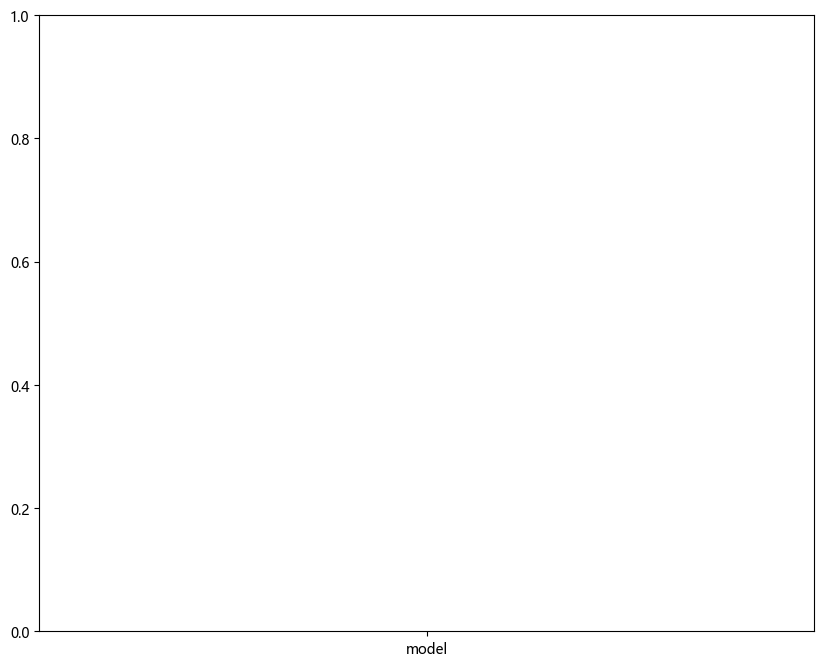

In [66]:
features=['model','brand','bodyType','fuelType','gearbox','power_perkilo','carage','price']
correlation_matrix=train[features].corr()
print('各个变量与价格的相关性')
print(correlation_matrix['price'].sort_values(ascending=False))
plt.figure(figsize=(10,8))
sns.lineplot(correlation_matrix,annot=True,cmap='coolwarm',center=0)
plt.title('各变量相关性折线图')
plt.show()

In [62]:
import os
os.chdir(r'C:\Users\yjw10\OneDrive\桌面\tianchi-price-prediction')
!git push
!git add --all
!git status
!git commit -m "补充说明，更新README文档和EDA代码"
!git push

fatal: unable to access 'https://github.com/jiawen-yu/tianchi-price-predicition/': Failed to connect to github.com port 443 after 21153 ms: Could not connect to server


On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   notebooks/01_EDA.ipynb

[main e9911d4] 琛ュ厖璇存槑锛屾洿鏂癛EADME鏂囨。鍜孍DA浠ｇ爜
 1 file changed, 136 insertions(+), 555 deletions(-)


To https://github.com/jiawen-yu/tianchi-price-predicition
   1afcbe5..e9911d4  main -> main
